Curator: Elizabeth Osborn

Reviewer: 

Title: Analysis of a Stochastic HBV Infection Model with DNA-Containing Capsids and Virions

Pathogen: Hepatitis B (HBV)

DOI: 10.1007/s00332-022-09883-w

Figure: 1

Outcome: Failed

Notes: Initial conditions are stated in Section 2 as x(0) > 0, l(0) > 0, y(0) > 0, v(0) > 0, w(0) > 0. No specific numerical values are 
given. Any positive initial values are valid per the authors.

In [1]:
variable_names = [
    "H",
    "I",
    "D",
    "V"
]
"""Names of the variables in the SDE model. The order of the variables should be the same as the order of the drift and diffusion terms returned by the drift_term and diffusion_term functions."""

parameter_names = [
    "s",
    "k",
    "mu",
    "delta",
    "a",
    "beta",
    "alpha",
    "c",
    "sigma1",
    "sigma2",
    "sigma3",
    "sigma4"
]
"""Names of the parameters in the SDE model. The order of the parameters should be the same as the order of the values returned by the drift_term and diffusion_term functions."""

initial_values = dict(
    H = 1,       # H > 0, Theorem 2.1 Undefined - see notes,
    I = 1,       # I > 0, Theorem 2.1 Undefined - see notes,
    D = 1,       # D > 0, Theorem 2.1 Undefined - see notes,
    V = 1        # V > 0, Theorem 2.1 Undefined - see notes
)
"""Dictionary of initial values for the variables in the SDE model. The keys should be the variable names in variable_names and the values should be the initial values for those variables."""

parameter_values = dict(
    s = 26000000.0,         # Table 2 for system 1.1, Section 5
    k = 0.000000000000167,  # Table 2 for system 1.1, Section 5
    mu = 0.01,              # Table 2 for system 1.1, Section 5
    delta = 0.053,          # Table 2 for system 1.1, Section 5
    a = 150.0,              # Table 2 for system 1.1, Section 5
    beta = 0.87,            # Table 2 for system 1.1, Section 5
    alpha = 0.25,           # Table 2 for system 1.1, Section 5
    c = 3.8,                # Table 2 for system 1.1, Section 5
    sigma1 = 0.03162,         # Table 2 for system 1.1, Section 5
    sigma2 = 0.03162,         # Table 2 for system 1.1, Section 5
    sigma3 = 0.03162,         # Table 2 for system 1.1, Section 5
    sigma4 = 0.03162          # Table 2 for system 1.1, Section 5
)
"""Dictionary of values for the parameters in the SDE model. The keys should be the parameter names in parameter_names and the values should be the values for those parameters."""

initial_time = 0.0
"""Initial time to simulate during testing and curation of the SDE model."""

final_time = 25000.0
"""Final time to simulate during testing and curation of the SDE model."""

def drift_term(t, y, p):
    """The drift term(s) of the SDE model
    Args:
        t: current time
        y: current values of the variables in the same order as variable_names
        p: current values of the parameters in the same order as parameter_names
    Returns:
        list: The drift term(s) of the SDE model in the same order as variable_names
    """
    h, i, d, v = y
    n = h + i + d + v
    s, k, mu, delta, a, beta, alpha, c, sigma1, sigma2, sigma3, sigma4 = p
    return [
        (s - k*h*v - mu*h),
        (k*h*v - delta*i),
        (a*i - beta*d - alpha*d),
        (beta*d - c*v)
    ]


def diffusion_term(t, y, p):
    """The diffusion term(s) of the SDE model
    Args:
        t: current time
        y: current values of the variables in the same order as variable_names
        p: current values of the parameters in the same order as parameter_names
    Returns:
        list: The diffusion term(s) of the SDE model in the same order as variable_names
    """
 
    h, i, d, v = y
    n = h + i + d + v
    s, k, mu, delta, a, beta, alpha, c, sigma1, sigma2, sigma3, sigma4 = p
    return [
        sigma1*h,
        sigma2*i,
        sigma3*d,
        sigma4*v
    ]

# End Curation

# Begin Testing

*Do not modify anything below this cell.*

Successful implementations can execute the cells below in order without error to produce a figure.

## Do checks

In [2]:
missing_ics = [n for n in variable_names if n not in initial_values]
missing_params = [n for n in parameter_names if n not in parameter_values]

found_errors = False
if len(missing_ics) > 0:
    print(f"Error: Missing initial values for variables: {missing_ics}")
    found_errors = True
if len(missing_params) > 0:
    print(f"Error: Missing values for parameters: {missing_params}")
    found_errors = True
test_drift = drift_term(initial_time, [initial_values[n] for n in variable_names], [parameter_values[n] for n in parameter_names])
test_diffusion = diffusion_term(initial_time, [initial_values[n] for n in variable_names], [parameter_values[n] for n in parameter_names])
if len(test_drift) != len(variable_names):
    print(f"Error: The drift term function should return a list of the same length as variable_names. Expected length {len(variable_names)}, but got {len(test_drift)}.")
    found_errors = True
if len(test_diffusion) != len(variable_names):
    print(f"Error: The diffusion term function should return a list of the same length as variable_names. Expected length {len(variable_names)}, but got {len(test_diffusion)}.")
    found_errors = True
if found_errors:
    raise ValueError("Failed to define the SDE model.")

## Do simulation test

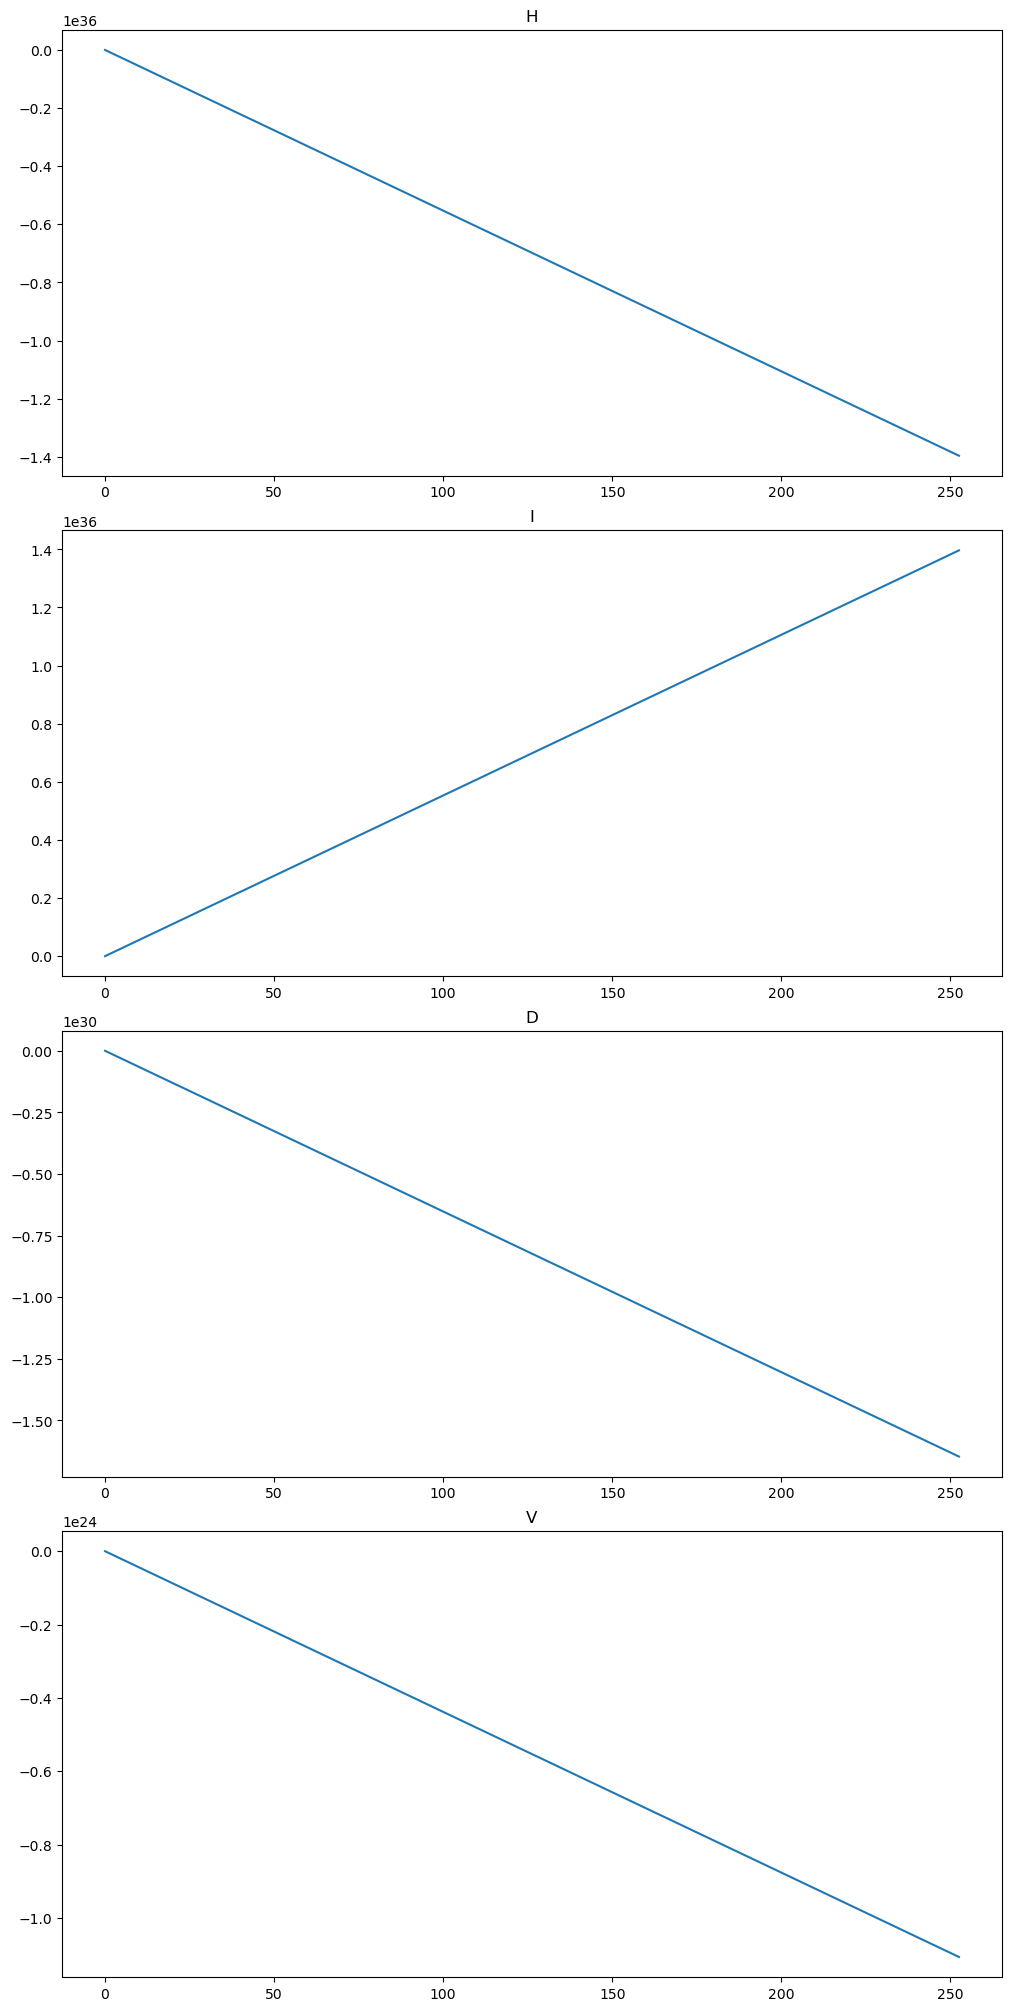

In [3]:
import diffrax
import jax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import numpy as np

sim_times = np.linspace(initial_time, final_time, 100)
dt = (final_time - initial_time) / 1000
dr_term = diffrax.ODETerm(lambda t, y, p: jnp.array(drift_term(t, y, p)))
br_term = diffrax.VirtualBrownianTree(t0=initial_time, t1=final_time, tol=dt / 10, shape=(), key=jax.random.PRNGKey(0))
di_term = diffrax.ControlTerm(lambda t, y, p: jnp.array(diffusion_term(t, y, p)), br_term)
sde_terms = diffrax.MultiTerm(dr_term, di_term)
solver = diffrax.Euler()
solution = diffrax.diffeqsolve(
    sde_terms,
    solver,
    t0=initial_time,
    t1=final_time,
    dt0=dt,
    y0=jnp.asarray([initial_values[n] for n in variable_names]),
    args=jnp.asarray([parameter_values[n] for n in parameter_names]),
    saveat=diffrax.SaveAt(ts=jnp.asarray(sim_times)),
    max_steps=None,
    throw=True
).ys

fig, axs = plt.subplots(len(variable_names), 1, figsize=(10, 5 * len(variable_names)), layout="constrained")
for i, name in enumerate(variable_names):
    axs[i].plot(sim_times, solution[:, i])
    axs[i].set_title(name)

In [4]:
print('Sucessfully defined the SDE model and generated a test simulation plot.')

Sucessfully defined the SDE model and generated a test simulation plot.
